In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor



In [2]:
df = pd.read_csv('housing.csv')
df = df.drop('ocean_proximity', axis=1)
df = df.drop('total_bedrooms', axis=1)
print(df.head())
print(df.info())
print(df.describe())
print("Пропуски:")
print(df.isnull().sum())


   longitude  latitude  housing_median_age  total_rooms  population  \
0    -122.23     37.88                  41          880         322   
1    -122.22     37.86                  21         7099        2401   
2    -122.24     37.85                  52         1467         496   
3    -122.25     37.85                  52         1274         558   
4    -122.25     37.85                  52         1627         565   

   households  median_income  median_house_value  
0         126         8.3252              452600  
1        1138         8.3014              358500  
2         177         7.2574              352100  
3         219         5.6431              341300  
4         259         3.8462              342200  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude          

In [3]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print(f"Матрица признаков: {X.shape}")
print(f"Признаки: {list(X.columns)}")
print(f"Диапазон целевой переменной: [{y.min():.2f}, {y.max():.2f}]")

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]}")
print(f"Тестовая выборка: {X_test.shape[0]}")

Матрица признаков: (20640, 7)
Признаки: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'population', 'households', 'median_income']
Диапазон целевой переменной: [14999.00, 500001.00]
Обучающая выборка: 16512
Тестовая выборка: 4128


Bagging Regressor

In [4]:
base_tree = DecisionTreeRegressor(max_depth=10, random_state=42)

bagging = BaggingRegressor(
    estimator=base_tree,
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)

mae_bagging = mean_absolute_error(y_test, y_pred_bagging)
mse_bagging = mean_squared_error(y_test, y_pred_bagging)
rmse_bagging = np.sqrt(mse_bagging)
r2_bagging = r2_score(y_test, y_pred_bagging)


print(f"Средняя абсолютная ошибка (MAE):      {mae_bagging:.2f}")
print(f"Средняя квадратичная ошибка (MSE):    {mse_bagging:.2f}")
print(f"RMSE:                                 {rmse_bagging:.2f}")
print(f"Коэффициент детерминации (R²):        {r2_bagging:.4f}")
print(f"Количество деревьев: {bagging.n_estimators}")

Средняя абсолютная ошибка (MAE):      36118.78
Средняя квадратичная ошибка (MSE):    2929288024.28
RMSE:                                 54122.90
Коэффициент детерминации (R²):        0.7765
Количество деревьев: 100


Random Forest Regressor

In [5]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)


print(f"Средняя абсолютная ошибка (MAE):      {mae_rf:.2f}")
print(f"Средняя квадратичная ошибка (MSE):    {mse_rf:.2f}")
print(f"RMSE:                                 {rmse_rf:.2f}")
print(f"Коэффициент детерминации (R²):        {r2_rf:.4f}")
print(f"Количество деревьев: {rf.n_estimators}")

feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Важность признаков:")
for idx, row in feature_importance_rf.iterrows():
    print(f"  {row['feature']:20s}: {row['importance']:.4f} ({row['importance']*100:.2f}%)")

Средняя абсолютная ошибка (MAE):      32443.18
Средняя квадратичная ошибка (MSE):    2507025767.09
RMSE:                                 50070.21
Коэффициент детерминации (R²):        0.8087
Количество деревьев: 100
Важность признаков:
  median_income       : 0.5408 (54.08%)
  longitude           : 0.1617 (16.17%)
  latitude            : 0.1518 (15.18%)
  housing_median_age  : 0.0642 (6.42%)
  population          : 0.0305 (3.05%)
  households          : 0.0263 (2.63%)
  total_rooms         : 0.0247 (2.47%)


Extra Trees Regressor

In [6]:
extra_trees = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

extra_trees.fit(X_train, y_train)
y_pred_et = extra_trees.predict(X_test)

mae_et = mean_absolute_error(y_test, y_pred_et)
mse_et = mean_squared_error(y_test, y_pred_et)
rmse_et = np.sqrt(mse_et)
r2_et = r2_score(y_test, y_pred_et)

print(f"Средняя абсолютная ошибка (MAE):      {mae_et:.2f}")
print(f"Средняя квадратичная ошибка (MSE):    {mse_et:.2f}")
print(f"RMSE:                                 {rmse_et:.2f}")
print(f"Коэффициент детерминации (R²):        {r2_et:.4f}")

Средняя абсолютная ошибка (MAE):      40556.59
Средняя квадратичная ошибка (MSE):    3583139204.95
RMSE:                                 59859.33
Коэффициент детерминации (R²):        0.7266


Модель AdaBoost

In [7]:
base_tree_shallow = DecisionTreeRegressor(max_depth=3, random_state=42)

adaboost = AdaBoostRegressor(
    estimator=base_tree_shallow,
    n_estimators=100,
    learning_rate=1.0,
    loss='linear',
    random_state=42
)

adaboost.fit(X_train, y_train)
y_pred_ada = adaboost.predict(X_test)

mae_ada = mean_absolute_error(y_test, y_pred_ada)
mse_ada = mean_squared_error(y_test, y_pred_ada)
rmse_ada = np.sqrt(mse_ada)
r2_ada = r2_score(y_test, y_pred_ada)

print(f"Средняя абсолютная ошибка (MAE):      {mae_ada:.2f}")
print(f"Средняя квадратичная ошибка (MSE):    {mse_ada:.2f}")
print(f"RMSE:                                 {rmse_ada:.2f}")
print(f"Коэффициент детерминации (R²):        {r2_ada:.4f}")
print(f"Количество слабых моделей: {adaboost.n_estimators}")

print(f"Вес первого оценщика: {adaboost.estimator_weights_[0]:.4f}")
print(f"Вес последнего оценщика: {adaboost.estimator_weights_[-1]:.4f}")

Средняя абсолютная ошибка (MAE):      74380.38
Средняя квадратичная ошибка (MSE):    7584185994.07
RMSE:                                 87087.23
Коэффициент детерминации (R²):        0.4212
Количество слабых моделей: 100
Вес первого оценщика: 1.6699
Вес последнего оценщика: 0.0000


Модель градиентного бустинга

In [8]:
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Средняя абсолютная ошибка (MAE):      {mae_gb:.2f}")
print(f"Средняя квадратичная ошибка (MSE):    {mse_gb:.2f}")
print(f"RMSE:                                 {rmse_gb:.2f}")
print(f"Коэффициент детерминации (R²):        {r2_gb:.4f}")
print(f"Количество деревьев: {gb.n_estimators}")
print(f"Глубина деревьев: {gb.max_depth}")

feature_importance_gb = pd.DataFrame({
    'feature': X.columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print("Важность признаков:")
for idx, row in feature_importance_gb.iterrows():
    print(f"  {row['feature']:20s}: {row['importance']:.4f} ({row['importance']*100:.2f}%)")

Средняя абсолютная ошибка (MAE):      38383.93
Средняя квадратичная ошибка (MSE):    3155259828.52
RMSE:                                 56171.70
Коэффициент детерминации (R²):        0.7592
Количество деревьев: 100
Глубина деревьев: 3
Важность признаков:
  median_income       : 0.6153 (61.53%)
  latitude            : 0.1426 (14.26%)
  longitude           : 0.1258 (12.58%)
  housing_median_age  : 0.0525 (5.25%)
  households          : 0.0308 (3.08%)
  population          : 0.0274 (2.74%)
  total_rooms         : 0.0056 (0.56%)


Сравнение качества моделей

In [ ]:
results = pd.DataFrame({
    'Модель': [
        'Bagging',
        'Random Forest',
        'Extra Trees',
        'AdaBoost',
        'Gradient Boosting'
    ],
    'MAE': [mae_bagging, mae_rf, mae_et, mae_ada, mae_gb],
    'RMSE': [rmse_bagging, rmse_rf, rmse_et, rmse_ada, rmse_gb],
    'R²': [r2_bagging, r2_rf, r2_et, r2_ada, r2_gb]
})


print(results.round({'MAE': 2, 'RMSE': 2, 'R²': 4}).to_string(index=False))

best_mae_idx = results['MAE'].idxmin()
best_rmse_idx = results['RMSE'].idxmin()
best_r2_idx = results['R²'].idxmax()

print(f"\n\nЛучшfя модель по MAE:  {results.loc[best_mae_idx, 'Модель']} {results.loc[best_mae_idx, 'MAE']:.2f}")
print(f"Лучшая модель по RMSE: {results.loc[best_rmse_idx, 'Модель']} {results.loc[best_rmse_idx, 'RMSE']:.2f}")
print(f"Лучшая модель по R²:   {results.loc[best_r2_idx, 'Модель']} {results.loc[best_r2_idx, 'R²']:.4f}")

           Модель      MAE     RMSE     R²
          Bagging 36118.78 54122.90 0.7765
    Random Forest 32443.18 50070.21 0.8087
      Extra Trees 40556.59 59859.33 0.7266
         AdaBoost 74380.38 87087.23 0.4212
Gradient Boosting 38383.93 56171.70 0.7592


Лучшая модель по MAE:  Random Forest 32443.18
Лучшая модель по RMSE: Random Forest 50070.21
Лучшая модель по R²:   Random Forest 0.8087


Визуализация результатов

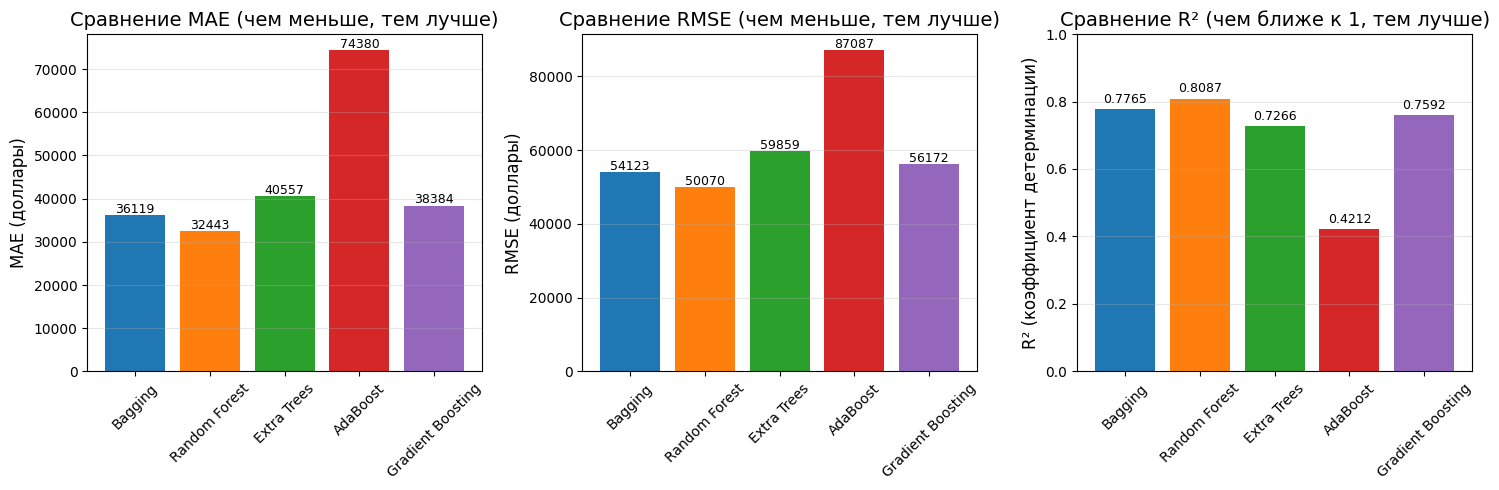

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
axes[0].bar(results['Модель'], results['MAE'], color=colors)
axes[0].set_ylabel('MAE (доллары)', fontsize=12)
axes[0].set_title('Сравнение MAE (чем меньше, тем лучше)', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

for i, (model, mae) in enumerate(zip(results['Модель'], results['MAE'])):
    axes[0].text(i, mae + 500, f'{mae:.0f}', ha='center', fontsize=9)

axes[1].bar(results['Модель'], results['RMSE'], color=colors)
axes[1].set_ylabel('RMSE (доллары)', fontsize=12)
axes[1].set_title('Сравнение RMSE (чем меньше, тем лучше)', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

for i, (model, rmse) in enumerate(zip(results['Модель'], results['RMSE'])):
    axes[1].text(i, rmse + 500, f'{rmse:.0f}', ha='center', fontsize=9)

axes[2].bar(results['Модель'], results['R²'], color=colors)
axes[2].set_ylabel('R² (коэффициент детерминации)', fontsize=12)
axes[2].set_title('Сравнение R² (чем ближе к 1, тем лучше)', fontsize=14)
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

for i, (model, r2) in enumerate(zip(results['Модель'], results['R²'])):
    axes[2].text(i, r2 + 0.02, f'{r2:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Выводы